In [ ]:
import pandas as pd
df = pd.read_csv("df_final.csv", index_col="date", parse_dates=True)

print(df.shape)
print(df.head())

(52440, 15)
                     price_eur_mwh  temperature  wind_speed  radiation  \
date                                                                     
2019-01-08 00:00:00          17.94          4.2        22.9        0.0   
2019-01-08 01:00:00          20.91          4.5        23.2        0.0   
2019-01-08 02:00:00           7.78          4.8        22.2        0.0   
2019-01-08 03:00:00          14.33          5.5        19.7        0.0   
2019-01-08 04:00:00          18.56          5.6        21.4        0.0   

                     precipitation  wind_power  solar_proxy  heating_degree  \
date                                                                          
2019-01-08 00:00:00            0.6   12008.989          0.0            13.8   
2019-01-08 01:00:00            0.5   12487.168          0.0            13.5   
2019-01-08 02:00:00            0.6   10941.048          0.0            13.2   
2019-01-08 03:00:00            1.3    7645.373          0.0            12.

Keep only necessary features out of DF 

In [2]:
FEATURES = [
    "wind_power", "solar_proxy", "heating_degree", "cooling_degree",
    "precipitation", "hour", "month", "is_weekend",
    "price_lag_24", "price_lag_168"
]
TARGET = "price_eur_mwh"

df_train = df["2019-01-01":"2022-12-31"]
df_val   = df["2023-01-01":"2023-12-31"]
df_test  = df["2024-01-01":"2024-12-31"]

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (34896, 10)
Validation: (8760, 10)
Test:       (8784, 10)


### Random Forrest

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ── Train ──────────────────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_val_pred_rf  = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_rf):.3f}")

print("\nRandom Forest — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_rf):.3f}")

Random Forest — Validation:
MAE:  25.78
RMSE: 35.24
R²:   0.451

Random Forest — Test:
MAE:  24.14
RMSE: 36.52
R²:   0.520


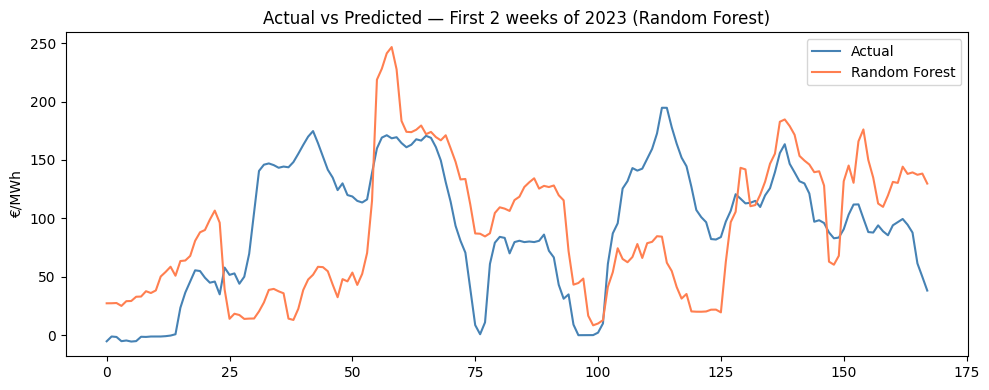

In [4]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 4))
plt.plot(y_val.values[:168], label="Actual", color="steelblue")
plt.plot(y_val_pred_rf[:168], label="Random Forest", color="coral")
plt.title("Actual vs Predicted — First 2 weeks of 2023 (Random Forest)")
plt.ylabel("€/MWh")
plt.legend()
plt.tight_layout()
plt.show()

1. The model underpredicts peaks — when actual price spikes to €175, model only predicts €90. It learned that high prices exist but is too conservative.
2. The model overpredicts at night — when actual drops to €0 or negative, model still predicts €25–50.

And increasing max_depth actually made metrics worse — the model started overfitting to training data.
Go back to max_depth=10 but let's fix the real problem — the model doesn't know the absolute price level has changed. The pattern is right but the scale is wrong.

This is exactly the gas price problem we discussed. Without it the model learned the shape from 2019–2022 but the 2023 baseline price is different.
For now let's try one simple fix — add year back temporarily just to give the model a sense of the price regime:

## XGBoost

In [5]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_val_pred_xgb  = xgb.predict(X_val)
y_test_pred_xgb = xgb.predict(X_test)

print("XGBoost — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_xgb):.3f}")

print("\nXGBoost — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_xgb):.3f}")

XGBoost — Validation:
MAE:  25.71
RMSE: 35.12
R²:   0.455

XGBoost — Test:
MAE:  23.39
RMSE: 34.60
R²:   0.569


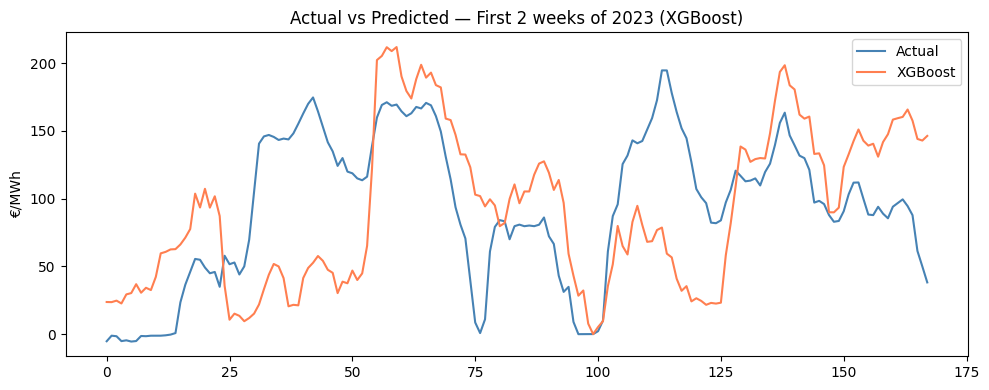

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(y_val.values[:168], label="Actual", color="steelblue")
plt.plot(y_val_pred_xgb[:168], label="XGBoost", color="coral")
plt.title("Actual vs Predicted — First 2 weeks of 2023 (XGBoost)")
plt.ylabel("€/MWh")
plt.legend()
plt.tight_layout()
plt.show()

## Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Linear regression needs scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_val_pred_lr  = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_lr):.3f}")

print("\nLinear Regression — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_lr):.3f}")

Linear Regression — Validation:
MAE:  22.82
RMSE: 32.39
R²:   0.537

Linear Regression — Test:
MAE:  23.23
RMSE: 36.63
R²:   0.517


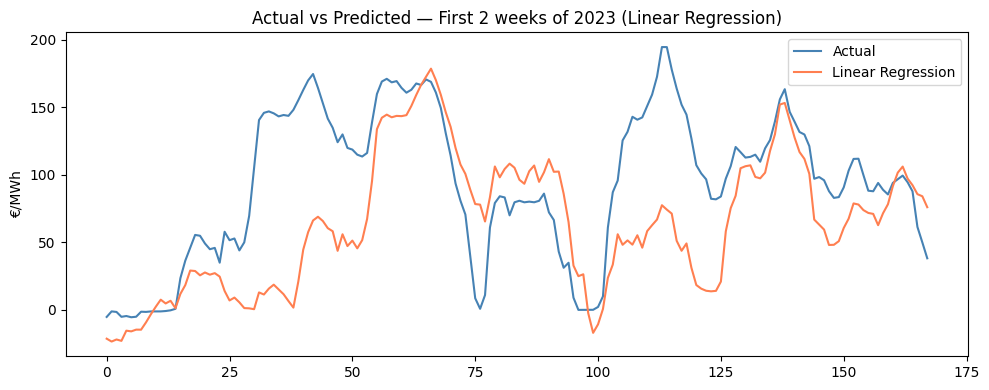

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(y_val.values[:168], label="Actual", color="steelblue")
plt.plot(y_val_pred_lr[:168], label="Linear Regression", color="coral")
plt.title("Actual vs Predicted — First 2 weeks of 2023 (Linear Regression)")
plt.ylabel("€/MWh")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
print(f"{'Model':<20} {'Dataset':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 70)

# Validation results — computed from actual predictions
print(f"{'Linear Regression':<20} {'Validation (2023)':<22} {mean_absolute_error(y_val, y_val_pred_lr):>8.2f} {np.sqrt(mean_squared_error(y_val, y_val_pred_lr)):>8.2f} {r2_score(y_val, y_val_pred_lr):>8.3f}")
print(f"{'Random Forest':<20} {'Validation (2023)':<22} {mean_absolute_error(y_val, y_val_pred_rf):>8.2f} {np.sqrt(mean_squared_error(y_val, y_val_pred_rf)):>8.2f} {r2_score(y_val, y_val_pred_rf):>8.3f}")
print(f"{'XGBoost':<20} {'Validation (2023)':<22} {mean_absolute_error(y_val, y_val_pred_xgb):>8.2f} {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):>8.2f} {r2_score(y_val, y_val_pred_xgb):>8.3f}")

print("-" * 70)

# Test results — computed from actual predictions
print(f"{'Linear Regression':<20} {'Test (2024)':<22} {mean_absolute_error(y_test, y_test_pred_lr):>8.2f} {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):>8.2f} {r2_score(y_test, y_test_pred_lr):>8.3f}")
print(f"{'Random Forest':<20} {'Test (2024)':<22} {mean_absolute_error(y_test, y_test_pred_rf):>8.2f} {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):>8.2f} {r2_score(y_test, y_test_pred_rf):>8.3f}")
print(f"{'XGBoost':<20} {'Test (2024)':<22} {mean_absolute_error(y_test, y_test_pred_xgb):>8.2f} {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):>8.2f} {r2_score(y_test, y_test_pred_xgb):>8.3f}")

Model                Dataset                     MAE     RMSE       R²
----------------------------------------------------------------------
Linear Regression    Validation (2023)         22.82    32.39    0.537
Random Forest        Validation (2023)         25.78    35.24    0.451
XGBoost              Validation (2023)         25.71    35.12    0.455
----------------------------------------------------------------------
Linear Regression    Test (2024)               23.23    36.63    0.517
Random Forest        Test (2024)               24.14    36.52    0.520
XGBoost              Test (2024)               23.39    34.60    0.569


### Key observations

**XGBoost is the best overall model** — lowest MAE (€23.39) and highest R² (0.569)
on the test set, meaning it explains 57% of price variation.

**Linear Regression wins on validation** but XGBoost generalizes better to the
unseen test year — suggesting XGBoost captures non-linear patterns that persist
beyond the validation period.

**All models are consistent** between validation and test — no model collapses
on unseen data, confirming the lag features are stable predictors.

**Lag features were the single biggest improvement** — adding yesterday's price
(lag_24) and last week's same-hour price (lag_168) lifted R² from negative values
to 0.45–0.57 across all models. This confirms that price momentum and weekly
demand cycles carry more predictive signal than weather features alone.

### Remaining limitation
R² of ~0.57 means 43% of price variation is still unexplained.
The missing signal is primarily the gas price level — a known limitation
of a weather-only model that would be addressed in future work.

## Feature importance

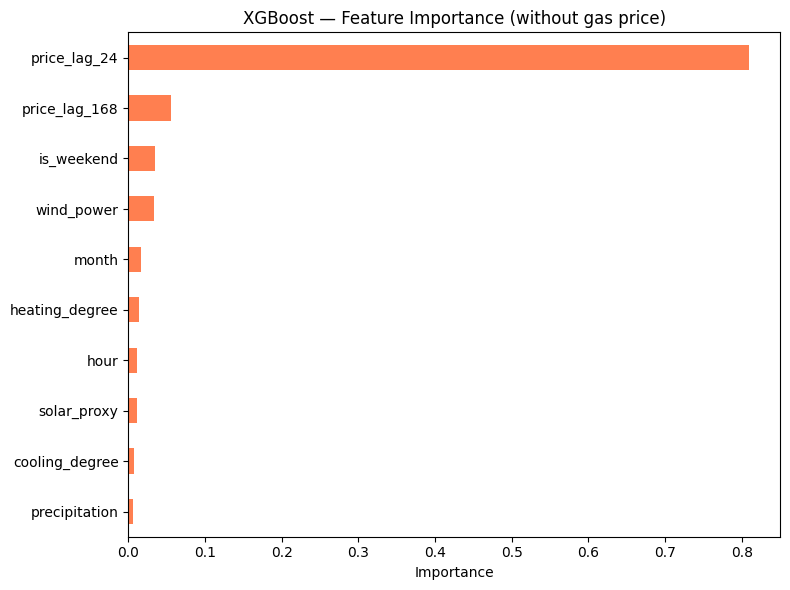

price_lag_24      0.809
price_lag_168     0.055
is_weekend        0.035
wind_power        0.033
month             0.016
heating_degree    0.014
hour              0.012
solar_proxy       0.011
cooling_degree    0.007
precipitation     0.007
dtype: float32


In [14]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
xgb_importance.plot(kind="barh", color="coral", edgecolor="none")
plt.title("XGBoost — Feature Importance (without gas price)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(xgb_importance.sort_values(ascending=False).round(3))

In [16]:
FEATURES_NO_LAG24 = [
    "wind_power", "solar_proxy", "heating_degree", "cooling_degree",
    "precipitation", "hour", "month", "is_weekend",
    "price_lag_168"
]

X_train_nl = df_train[FEATURES_NO_LAG24]
X_val_nl   = df_val[FEATURES_NO_LAG24]
X_test_nl  = df_test[FEATURES_NO_LAG24]

xgb_nl = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_nl.fit(X_train_nl, y_train)

y_val_pred_nl  = xgb_nl.predict(X_val_nl)
y_test_pred_nl = xgb_nl.predict(X_test_nl)

print("XGBoost WITHOUT price_lag_24 — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_nl):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_nl)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_nl):.3f}")

print("\nXGBoost WITHOUT price_lag_24 — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_nl):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_nl)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_nl):.3f}")

XGBoost WITHOUT price_lag_24 — Validation:
MAE:  40.01
RMSE: 53.47
R²:   -0.263

XGBoost WITHOUT price_lag_24 — Test:
MAE:  34.76
RMSE: 49.25
R²:   0.128
